<a href="https://colab.research.google.com/github/hanmtay/IntroToAI_A2/blob/main/section2_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!git clone https://github.com/hanmtay/IntroToAI_A2.git
%cd IntroToAI_A2

fatal: destination path 'IntroToAI_A2' already exists and is not an empty directory.
/content/IntroToAI_A2


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

loading in data

In [5]:
df = pd.read_csv('a2_Hannah_Taylor_40443054/40443054_features.csv')

features chosen

In [6]:
my_features = ['rows_with_1', 'cols_with_2', 'hollowness', 'height']

Task 2.1

k Value    | Accuracy (%)   
------------------------------
1          | 100.00         
3          | 95.54          
5          | 94.64          
7          | 91.07          
9          | 91.96          
11         | 91.07          
13         | 91.07          
15         | 90.18          


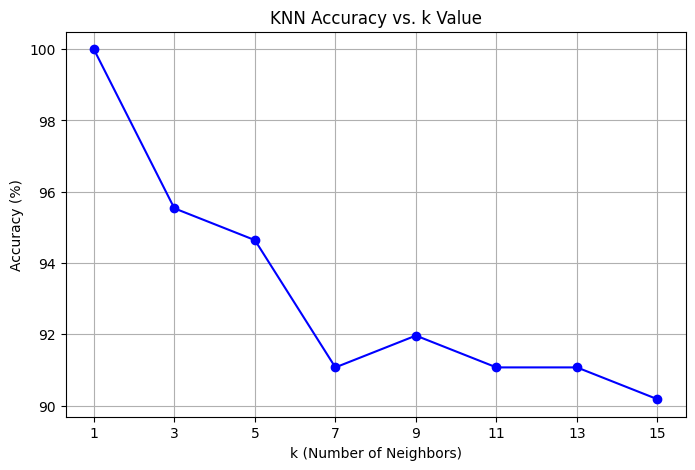

In [7]:
X = df[my_features]
y = df['label']

k_values = [1, 3, 5, 7, 9, 11, 13, 15]

#store results from knn
results = []

print(f"{'k Value':<10} | {'Accuracy (%)':<15}")
print("-" * 30)

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)


    knn.fit(X, y)

    y_pred = knn.predict(X)

    acc = accuracy_score(y, y_pred) * 100
    results.append(acc)

    print(f"{k:<10} | {acc:<15.2f}")


plt.figure(figsize=(8, 5))
plt.plot(k_values, results, marker='o', linestyle='-', color='b')
plt.title('KNN Accuracy vs. k Value')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy (%)')
plt.xticks(k_values)
plt.grid(True)
plt.savefig('KNN21.png')
plt.show()

Task 2.2

k Value    | CV Accuracy (%)
-----------------------------------
1          | 90.18          
3          | 91.07          
5          | 88.39          
7          | 90.18          
9          | 87.50          
11         | 87.50          
13         | 85.71          
15         | 83.04          


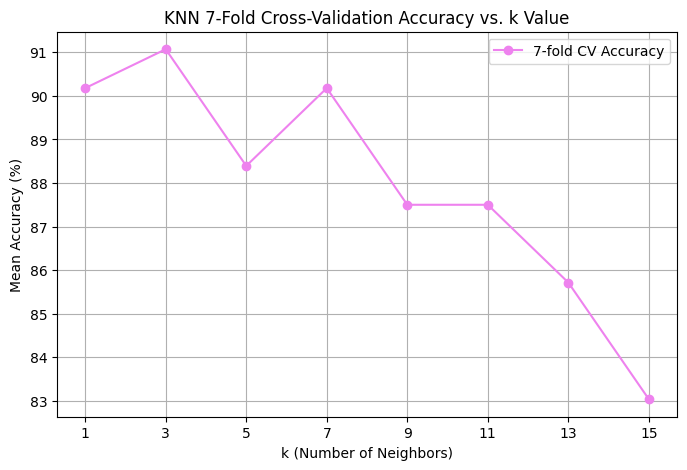

In [8]:
#same X and y from above

#7 fold cv
kf = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

#store cv results
cv_results = []

print(f"{'k Value':<10} | {'CV Accuracy (%)':<15}")
print("-" * 35)

for k in k_values:

    knn_cv = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn_cv, X, y, cv=kf)

    mean_acc = scores.mean() * 100
    cv_results.append(mean_acc)

    print(f"{k:<10} | {mean_acc:<15.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_results, marker='o', linestyle='-', color='violet', label='7-fold CV Accuracy')
plt.title('KNN 7-Fold Cross-Validation Accuracy vs. k Value')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Mean Accuracy (%)')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.savefig('KNN22_CV.png')
plt.show()

task 2.3

<Figure size 1000x800 with 0 Axes>

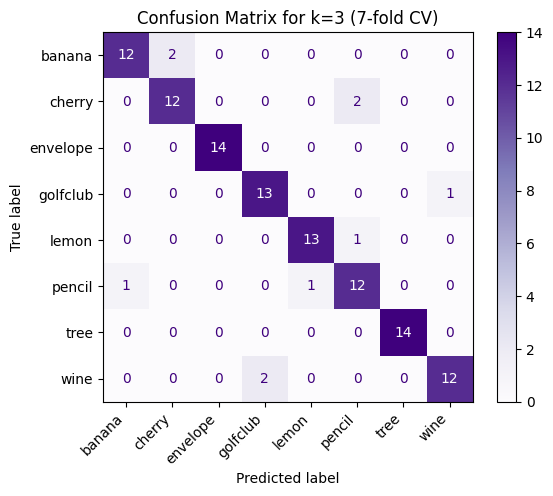

In [18]:
#best k value from above is 3
knn_best = KNeighborsClassifier(n_neighbors=3)
y_pred_cv = cross_val_predict(knn_best, X, y, cv=kf)

cm = confusion_matrix(y, y_pred_cv)
#from: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Purples', values_format='d')
# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')
plt.title(f'Confusion Matrix for k={3} (7-fold CV)')
plt.savefig('cm23.png')
plt.show()